В этом блокноте мы исследуем важные концепции в машинном обучении, связанные с обучением нейронных сетей: недообучение и переобучение. Мы продемонстрируем, как эти проблемы проявляются, и изучим методы борьбы с переобучением, такие как Dropout и L2-регуляризация. Мы будем использовать датасет Fashion MNIST для наглядной демонстрации этих концепций.  Особое внимание уделим анализу кривых обучения и оценке качества моделей на тестовых данных.

### Импортируем данные и необходимые библиотеки

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

Будем использовать лишь фрагмент из всего набора данных, чтобы сократить временные затраты на обучение моделей.

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train[:5000]
X_test = X_test[:1000]
y_train = y_train[:5000]
y_test = y_test[:1000]

Данные — значения интенсивностей пикселей и лежат в пределах $[0,255]$. "Распрямим" и масштабируем, чтобы получить значения из отрезка $[0,1]$.

In [ ]:
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

Задача — многоклассовая классификация, поэтому произведем `one-hot` кодирование откликов.

In [ ]:
y_train = np.eye(10)[y_train]

### Базовая модель

Построим самую простую модель: каждому классу ставим в соответствие один нейрон.
* Активация — `softmax`
* Оптимизатор — `adam`
* Лосс — `categorical_crossentropy`
* Метрика — `accuracy`
* Число эпох обучения — `10`
* `batch_size=256`
* `validation_split=0.2`


In [ ]:
# <YOUR CODE HERE>

График лосса для `train` и `validation`

In [ ]:
# <YOUR CODE HERE>

Что можно сказать по графику?

Оценим модель на тестовых данных

In [ ]:
# <YOUR CODE HERE>

Увеличим число эпох обучения до 30

In [ ]:
# <YOUR CODE HERE>

Графики лосса

In [ ]:
# <YOUR CODE HERE>

Что можно сказать по графику?

Оценим модель на тестовых данных

In [ ]:
# <YOUR CODE HERE>

### Усложняем модель

Очевидно, предыдущая модель слишком простая, хотя на деле не так плоха. Изменим архитектуру:

* Скрытые слои со следующим числом нейронов: `(1024, 512, 256)`. Активация — `relu`
* Установим `verbose=1` в методе `.fit()`, чтобы остлеживать прогресс
* Остальные параметры без изменений

In [ ]:
# <YOUR CODE HERE>

График лоссов

In [ ]:
# <YOUR CODE HERE>

Что можно сказать, глядя на графики лоссов? А если еще увеличить число эпох?

Оценка на тесте

In [ ]:
# <YOUR CODE HERE>

### Регуляризация

Для борьбы с переобучением часто используют Dropout и регуляризацию. Dropout случайным образом "выключает" часть нейронов во время обучения, что заставляет сети "перераспределять" обязанности нейронов и не слишком полагаться на конкретные нейроны. Регуляризация добавляет штраф к функции потерь за большие значения весов, что препятствует сети слишком сильно подстраиваться под тренировочные данные.

In [ ]:
regularized_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(512, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu', kernel_regularizer='l2'),
    layers.Dropout(0.1),
    layers.Dense(10, activation='softmax')
])

regularized_model.compile(optimizer='adam',
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

history = regularized_model.fit(X_train, y_train,
                          epochs=30,
                          batch_size=256,
                          validation_split=0.2,
                          verbose=1)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.4131 - loss: 10.4596 - val_accuracy: 0.7500 - val_loss: 7.1625
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7107 - loss: 6.6433 - val_accuracy: 0.8110 - val_loss: 4.7714
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7549 - loss: 4.4919 - val_accuracy: 0.8260 - val_loss: 3.3166
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7947 - loss: 3.1526 - val_accuracy: 0.8400 - val_loss: 2.4409
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7945 - loss: 2.3826 - val_accuracy: 0.8210 - val_loss: 1.9321
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7874 - loss: 1.9238 - val_accuracy: 0.8180 - val_loss: 1.6026
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8047 - loss: 1.6139 - val_accuracy: 0.8420 - val_loss: 1.3442
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8197 - loss: 1.3494 - val_accuracy: 0.8420 - 

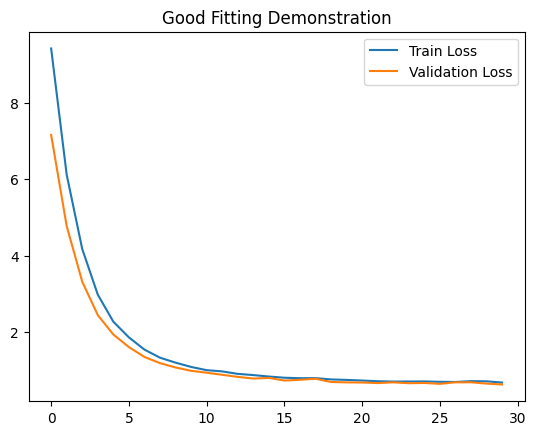

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Good Fitting Demonstration')
plt.legend()
plt.show()

In [ ]:
predictions_logits = regularized_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


0.827

### Больше данных

Объем данных существенно влияет на обучение и качество сети. Возьмем весь набор данных и обучим на нем самую простую и самую сложную из рассмотренных моделей.

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0
y_train = np.eye(10)[y_train]

#### Маленькая модель

In [ ]:
small_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(10, activation='softmax')
])

small_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history = small_model.fit(X_train, y_train,
                                   epochs=30,
                                   batch_size=256,
                                   validation_split=0.2,
                                   verbose=0)

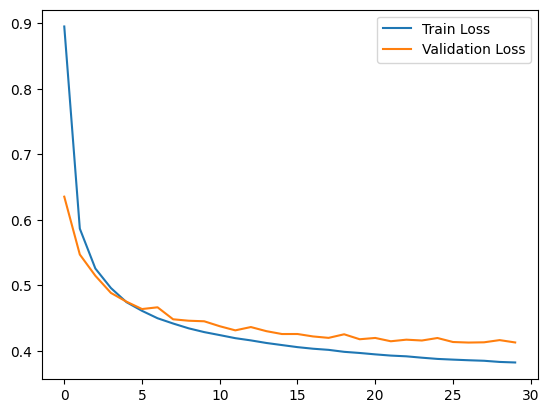

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [ ]:
predictions_logits = small_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


0.8463

Видно, что дальнейшее увеличение данных при данной архитектуре дает некоторый прирост метрики, но, похоже мы выжали из этой модели максимум.

#### Большая модель

Возьмем сразу не очень большое число эпох, например, 10

In [ ]:
big_model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

big_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history = big_model.fit(X_train, y_train,
                          epochs=10,
                          batch_size=256,
                          validation_split=0.2,
                          verbose=1)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.7384 - loss: 0.7449 - val_accuracy: 0.8575 - val_loss: 0.3996
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.8612 - loss: 0.3767 - val_accuracy: 0.8743 - val_loss: 0.3478
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.8790 - loss: 0.3266 - val_accuracy: 0.8798 - val_loss: 0.3357
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.8882 - loss: 0.2989 - val_accuracy: 0.8792 - val_loss: 0.3269
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8955 - loss: 0.2801 - val_accuracy: 0.8854 - val_loss: 0.3172
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9010 - loss: 0.2628 - val_accuracy: 0.8867 - val_loss: 0.3222
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9061 - loss: 0.2510 - val_accuracy: 0.8817 - val_loss: 0.3291
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.9113 - loss: 0.2335 - 

In [ ]:
predictions_logits = big_model.predict(X_test)
y_pred = np.argmax(predictions_logits, axis=1)
accuracy_score(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


0.8831